# Vectorless RAG: Multi-Hop Question Answering & Structured Tables

<!-- Lab Doc §1 (Title) + §2 (Problem Statement / Use Case Overview) -->

This notebook demonstrates two advanced use cases where Vectorless RAG outperforms standard chunking-based RAG:

1. **Multi-Hop Question Answering** — fetching discrete variables (dates, limits, conditions) from different parts of a document without introducing noise.
2. **Structured Tables & Rate Charts** — retrieving whole logical nodes that preserve table structure, headers, and footnotes.

Standard Vector RAG often fails here because:
- Chunking shatters tables and cross-references.
- Embedding similarity retrieves irrelevant nearby text.
- Multi-hop reasoning requires fetching multiple distant nodes, which chunking mixes together.

## 1. Prerequisites

<!-- Lab Doc §8 (Pre-requisites) + §3 (Input Data) -->

This notebook assumes you have:

- Documents in a local `data/` folder (PDF, DOCX, TXT, MD, HTML, or CSV).
- A PageIndex API key for tree generation.
- An OpenRouter API key for the free LLM endpoint.

The LLM layer uses [OpenRouter](https://openrouter.ai/) via its OpenAI-compatible endpoint. It uses `openrouter/free` which automatically selects from available free models. The resolved model name is printed on the first LLM call.

**Supported file types:** PDF (native), DOCX, TXT, MD, HTML, CSV (auto-converted to PDF). Multiple files of different types can be uploaded simultaneously.

### API Key Setup

You will need two API keys:

| Key | Where to get it |
|-----|------------------|
| `OPENROUTER_API_KEY` | [https://openrouter.ai/keys](https://openrouter.ai/keys) |
| `PAGEINDEX_API_KEY` | [https://www.pageindex.ai](https://www.pageindex.ai) |

Set them as environment variables or in a `.env` file in the same directory as this notebook:

```
OPENROUTER_API_KEY=sk-or-v1-...
PAGEINDEX_API_KEY=...
```

In [1]:
# Block 1: Install dependencies
%pip install -q --upgrade pageindex openai python-dotenv pymupdf networkx matplotlib scipy ipywidgets python-docx reportlab 

Note: you may need to restart the kernel to use updated packages.


## 2. Configuration

<!-- Lab Doc §6 (Tech Stack) + §9 (Environment / Dependencies Setup) -->

The notebook reads API keys from a `.env` file or environment variables. If neither is set, you'll be prompted to paste them interactively.

- `OPENROUTER_API_KEY`: OpenRouter API key (from [openrouter.ai/keys](https://openrouter.ai/keys)).
- `PAGEINDEX_API_KEY`: PageIndex API key.

The notebook uses `openrouter/free` which automatically selects from available free models. The actual model used is printed on the first LLM call.

OpenRouter provides an OpenAI-compatible endpoint with access to multiple models.

In [1]:
from pathlib import Path
import asyncio
import hashlib
import json
import logging
import os
import re
import time
from logging.handlers import RotatingFileHandler
from typing import Any

from dotenv import load_dotenv
from openai import AsyncOpenAI, RateLimitError
from pageindex import PageIndexClient
import pageindex.utils as pi_utils

load_dotenv()

DATA_DIR = Path("data")
CACHE_DIR = DATA_DIR / "cache"

DATA_DIR.mkdir(exist_ok=True)
_log_file_handler = RotatingFileHandler(DATA_DIR / "pipeline.log", maxBytes=5_000_000, backupCount=3)
_log_file_handler.setLevel(logging.INFO)
_log_console_handler = logging.StreamHandler()
_log_console_handler.setLevel(logging.WARNING)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[_log_file_handler, _log_console_handler],
)
logger = logging.getLogger("vectorless_rag")

# Suppress noisy third-party loggers (HTTP request lines, SDK internals)
# below WARNING on both file and console — they are pure noise.
for _lib in ("httpx", "httpcore", "openai"):
    logging.getLogger(_lib).setLevel(logging.WARNING)
LLM_BASE_URL = "https://openrouter.ai/api/v1"
PDF_NAME = os.getenv("PDF_NAME")

# Load keys from .env, or prompt user to enter them (masked)
from getpass import getpass

PAGEINDEX_API_KEY = os.getenv("PAGEINDEX_API_KEY", "").strip()
LLM_API_KEY = os.getenv("OPENROUTER_API_KEY", "").strip()

if not PAGEINDEX_API_KEY:
    PAGEINDEX_API_KEY = getpass("Paste your PAGEINDEX_API_KEY (from pageindex.ai): ").strip()
if not LLM_API_KEY:
    LLM_API_KEY = getpass("Paste your OPENROUTER_API_KEY (from openrouter.ai/keys): ").strip()

print(f"PAGEINDEX_API_KEY: {'set' if PAGEINDEX_API_KEY else 'NOT SET'}")
print(f"OPENROUTER_API_KEY: {'set' if LLM_API_KEY else 'NOT SET'}")

LLM_MODEL = "openrouter/free"
print(f"Using model: {LLM_MODEL}")

pi_client = PageIndexClient(api_key=PAGEINDEX_API_KEY) if PAGEINDEX_API_KEY else None
llm_client = AsyncOpenAI(api_key=LLM_API_KEY, base_url=LLM_BASE_URL) if LLM_API_KEY else None
_openrouter_model_printed = False


# Block 2: Configuration — shared safety layer used by every LLM call below.

def extract_json(text: str) -> dict[str, Any]:
    """Extract the first JSON object found in arbitrary LLM output.

    LLMs sometimes wrap JSON in markdown fences or prepend explanation
    text. This helper finds the first '{...}' block and parses it,
    raising ValueError if nothing parseable is found.

    Parameters
    ----------
    text : str
        Raw LLM response, possibly containing non-JSON preamble.

    Returns
    -------
    dict[str, Any]
        The parsed JSON object.

    Raises
    ------
    ValueError
        If no valid JSON object can be extracted.
"""
    match = re.search(r"\{.*\}", text, re.S)
    if not match:
        raise ValueError(f"Expected JSON output, got: {text[:500]}")
    return json.loads(match.group(0))


async def call_llm(system_prompt: str, user_prompt: str, model: str = LLM_MODEL, temperature: float = 0.0) -> str:
    """Send a chat completion request to the LLM with automatic retry on rate limits.

    This is the shared safety layer for every LLM call in the pipeline.
    It retries up to 4 times on RateLimitError with exponential backoff
    (1s, 2s, 4s) before giving up.

    Parameters
    ----------
    system_prompt : str
        The system-level instruction that shapes the model's behaviour.
    user_prompt : str
        The user-facing prompt (question, evidence, tree, etc.).
    model : str, optional
        LLM model ID. Defaults to the globally-selected LLM_MODEL.
    temperature : float, optional
        Sampling temperature. Defaults to 0.0 for deterministic output.

    Returns
    -------
    str
        The model's response text, stripped of leading/trailing whitespace.

    Side effects
    ------------
    - Logs a warning and prints a message on each rate-limit retry.
    - Raises RuntimeError if all 4 attempts are exhausted.
"""
    if llm_client is None:
        raise RuntimeError("OPENROUTER_API_KEY is not configured.")
    global _openrouter_model_printed
    max_attempts = 4
    for attempt in range(1, max_attempts + 1):
        try:
            response = await llm_client.chat.completions.create(
                model=model,
                temperature=temperature,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt},
                ],
            )
            if not _openrouter_model_printed:
                print(f"\U0001f916 OpenRouter resolved model: {response.model}")
                _openrouter_model_printed = True
            return response.choices[0].message.content.strip()
        except RateLimitError:
            if attempt == max_attempts:
                raise RuntimeError("LLM service is busy, please try again shortly.") from None
            wait = 2 ** (attempt - 1)
            logger.warning("Rate limited, retrying in %ds... (attempt %d/4)", wait, attempt)
            print(f"Rate limited, retrying in {wait}s... (attempt {attempt}/4)")
            await asyncio.sleep(wait)


async def call_llm_and_parse(system_prompt: str, user_prompt: str, model: str = LLM_MODEL, temperature: float = 0.0) -> dict[str, Any]:
    """Call the LLM and guarantee a parsed JSON dict is returned.

    Wraps call_llm + extract_json. If the first reply is not valid JSON,
    sends a corrective retry asking the model to return only JSON. If the
    second attempt also fails, raises RuntimeError.

    Parameters
    ----------
    system_prompt, user_prompt, model, temperature
        Forwarded directly to call_llm (see its docstring).

    Returns
    -------
    dict[str, Any]
        The parsed JSON object from the model's response.

    Side effects
    ------------
    - Can trigger up to 3 total LLM calls (1 initial + 1 corrective + 1
      inside call_llm's own retry loop) before giving up.
    - Logs a warning when the corrective retry is triggered.
"""
    reply = await call_llm(system_prompt, user_prompt, model, temperature)
    try:
        return extract_json(reply)
    except ValueError:
        logger.warning("Received malformed JSON from LLM, sending corrective retry...")
        print("Received malformed JSON, sending one corrective retry...")
        corrective_prompt = f"Your previous reply was not valid JSON:\n\n{reply}\n\nReturn ONLY the valid JSON object, with no extra text, no markdown fences, and no explanation."
        reply2 = await call_llm(system_prompt, corrective_prompt, model, temperature)
        try:
            return extract_json(reply2)
        except ValueError:
            raise RuntimeError("The AI model failed to return valid JSON after 2 attempts. Please try rephrasing your question.")


def preview_text(text: str, limit: int = 1200) -> str:
    """Truncate long text for display in notebook output cells.

    If the text exceeds *limit* characters, it is cut at that boundary
    and an ellipsis is appended. Used to keep evidence previews readable.

    Parameters
    ----------
    text : str
        The text to preview.
    limit : int, optional
        Maximum characters before truncation. Defaults to 1200.

    Returns
    -------
    str
        The original text (if short enough) or a truncated version.
"""
    text = text.strip()
    return text if len(text) <= limit else text[:limit].rstrip() + "..."


import fitz  # PyMuPDF


def extract_raw_page_text(pdf_path: Path, page_index: int) -> str:
    """Extract raw text from a single PDF page using PyMuPDF.

    This is independent of PageIndex — used by the backfill logic to
    cross-check and supplement nodes whose indexed text looks incomplete.

    Parameters
    ----------
    pdf_path : Path
        Filesystem path to the PDF document.
    page_index : int
        0-based page number to extract.

    Returns
    -------
    str
        The page's raw text, or "" on error or out-of-range index.
"""
    try:
        doc = fitz.open(pdf_path)
        if 0 <= page_index < len(doc):
            text = doc[page_index].get_text()
            doc.close()
            return text
        doc.close()
        return ""
    except Exception:
        return ""


def find_matching_page_text(pdf_path: Path, node_title: str, approx_page_index: int, search_radius: int = 2) -> str:
    """Find the correct PDF page for a node by verifying its title appears there.

    The node's page_index from PageIndex may not align exactly with
    PyMuPDF's 0-based page numbering (off-by-one or other offset is
    possible). Instead of trusting approx_page_index blindly, this
    function searches a small window of nearby pages and returns the
    text of whichever page actually contains the node's own title.

    Parameters
    ----------
    pdf_path : Path — Filesystem path to the PDF.
    node_title : str — The title string of the document node.
    approx_page_index : int — Page index reported by PageIndex (may be off).
    search_radius : int — How many pages on each side to search (default 2).

    Returns
    -------
    str — The raw page text of the best-matching page, or "" if none match.
"""
    if not node_title or not node_title.strip():
        return ""
    title_snippet = node_title.strip()[:40].lower()
    candidates = []
    for offset in range(-search_radius, search_radius + 1):
        candidate_page = approx_page_index + offset
        text = extract_raw_page_text(pdf_path, candidate_page)
        if text and title_snippet in text.lower():
            candidates.append((abs(offset), text))
    if not candidates:
        return ""
    candidates.sort(key=lambda pair: pair[0])
    return candidates[0][1]


def find_continuation_page_text(pdf_path: Path, node_title: str, page_idx: int) -> str:
    """Detect if the next PDF page continues this node's section.

    Large sections often span page breaks in the source PDF. PageIndex
    may split them into separate nodes, or the node's text may end mid-
    sentence. This function checks whether the page immediately after
    *page_idx* repeats the section title (a strong signal of continuation)
    and returns that page's raw text if so.

    The check is independent of how much text the node already has — a
    node can be long enough to look complete and still be missing a
    continuation on the next page.

    Parameters
    ----------
    pdf_path : Path — Filesystem path to the PDF.
    node_title : str — The section title to look for on the next page.
    page_idx : int — 0-based page index of the current node.

    Returns
    -------
    str — The next page's raw text if it continues this section, else "".
"""
    if not node_title or not node_title.strip():
        return ""
    next_page_text = extract_raw_page_text(pdf_path, page_idx + 1)
    if not next_page_text:
        return ""
    # Normalize both strings: lowercase, strip punctuation, collapse whitespace.
    # This makes the match robust to minor formatting differences across pages.
    import re as _re
    def _normalize(s: str) -> str:
        s = _re.sub(r"[^a-z0-9 ]", " ", s.lower())
        return _re.sub(r"\s+", " ", s).strip()
    title_normalized = _normalize(node_title.strip()[:40])
    next_page_normalized = _normalize(next_page_text[:300])
    # If the section title appears in the first ~300 chars of the next page,
    # it almost certainly continues this section (e.g. 'Section 10 Endorsements'
    # repeated at the top of the next page).
    if title_normalized and title_normalized in next_page_normalized:
        return next_page_text
    return ""


def verify_and_backfill_tree(tree: list, pdf_path: Path, min_chars_per_page: int = 400) -> list:
    """Cross-check every node's text against raw PDF extraction and fill gaps.

    PageIndex's indexed text is usually complete, but occasionally a node
    ends up with suspiciously little text (e.g. only a heading). This
    function walks the full tree and, for any short node, extracts the
    corresponding page via PyMuPDF. If the raw extraction is meaningfully
    longer (>1.5x and > min_chars), the extra text is appended so nothing
    is silently missing from retrieval.

    It also checks for page-continuation content on the following page.

    Parameters
    ----------
    tree : list — The PageIndex document tree (list of root nodes).
    pdf_path : Path — Filesystem path to the original PDF.
    min_chars_per_page : int — Threshold below which a node is considered short (default 400).

    Returns
    -------
    list — The same tree, modified in place with backfilled text where needed.

    Side effects
    ------------
    - Mutates the tree in place (appends supplemental text to node["text"]).
    - Prints which nodes were backfilled, or a pass confirmation.
"""
    backfilled_nodes = []

    def walk(nodes):
        for node in nodes:
            node_text = node.get("text", "") or ""
            page_idx = node.get("page_index")
            node_title = node.get("title", "")
            # Backfill 1: if node text is suspiciously short, pull raw text
            # from the verified page and append if it's meaningfully longer.
            if page_idx is not None and len(node_text) < min_chars_per_page:
                raw_text = find_matching_page_text(pdf_path, node_title, page_idx)
                if raw_text and len(raw_text) > len(node_text) * 1.5 and len(raw_text) > min_chars_per_page:
                    node["text"] = (node_text + "\n\n[Supplemental content recovered via verified raw PDF "
                                     "extraction, since the indexed section text appeared incomplete:]\n\n" + raw_text)
                    backfilled_nodes.append(node.get("node_id", node.get("title", "unknown")))
            # Backfill 2: even if the node looks long enough, check whether
            # the next page continues this section (title repeated).
            if page_idx is not None:
                continuation_text = find_continuation_page_text(pdf_path, node_title, page_idx)
                if continuation_text and continuation_text not in node["text"]:
                    node["text"] = (node["text"] + "\n\n[Additional continuation content recovered "
                                     "via verified raw PDF extraction from the following page:]\n\n" + continuation_text)
                    backfilled_nodes.append(node.get("node_id", node.get("title", "unknown")) + " (continuation)")

            children = node.get("nodes") or node.get("children") or []
            if children:
                walk(children)

    walk(tree)

    if backfilled_nodes:
        print(f"\u26a0\ufe0f  Backfilled {len(backfilled_nodes)} node(s) that looked incomplete: {backfilled_nodes}")
        print("   (Supplemented using local PyMuPDF extraction \u2014 no additional PageIndex calls were made.)")
    else:
        print("\u2705 Tree completeness check passed \u2014 no nodes appeared truncated.")

    return tree

PAGEINDEX_API_KEY: set
OPENROUTER_API_KEY: set
Using model: openrouter/free


## 3. Load documents from `data/`

<!-- Lab Doc §3 (Input Data) + §4 Processing: PDF Document → PageIndex Client -->

This notebook supports multiple documents simultaneously. Place your files (PDF, DOCX, TXT, MD, HTML, or CSV) in the `data/` folder, then run this cell to select which ones to use.

Non-PDF files are automatically converted to PDF before indexing. Converted files are stored in `data/converted/`.

In [2]:
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path
import subprocess
import sys
import textwrap
import fitz  # PyMuPDF

DATA_DIR.mkdir(exist_ok=True)
CONVERTED_DIR = DATA_DIR / "converted"
CONVERTED_DIR.mkdir(exist_ok=True)

SUPPORTED_NATIVE = {".pdf"}
SUPPORTED_CONVERT = {".docx", ".txt", ".md", ".html", ".csv"}
ALL_SUPPORTED = SUPPORTED_NATIVE | SUPPORTED_CONVERT

def _convert_docx(src: Path, dest_pdf: Path) -> bool:
    try:
        lo = "/Applications/LibreOffice.app/Contents/MacOS/soffice"
        if not Path(lo).exists():
            lo = "libreoffice"
        subprocess.run([lo, "--headless", "--convert-to", "pdf", "--outdir", str(dest_pdf.parent), str(src)],
                       capture_output=True, timeout=120, check=True)
        converted = dest_pdf.parent / (src.stem + ".pdf")
        if converted.exists() and converted != dest_pdf:
            converted.rename(dest_pdf)
        return dest_pdf.exists()
    except Exception as e:
        print(f"  Warning: DOCX conversion failed ({e}).")
        return False

def _convert_text(src: Path, dest_pdf: Path) -> bool:
    try:
        text = src.read_text(encoding="utf-8", errors="replace")
        doc = fitz.open()
        
        page_w, page_h = 595.0, 842.0
        margin = 50
        font_size = 10
        line_height = font_size * 1.4
        
        lines = text.splitlines()
        page = doc.new_page(width=page_w, height=page_h)
        y_offset = margin

        for line in lines:
            if not line.strip():
                y_offset += line_height
            else:
                # Wrap text if it exceeds page width
                wrapped = textwrap.wrap(line, width=80)
                for w_line in wrapped:
                    if y_offset > (page_h - margin):
                        page = doc.new_page(width=page_w, height=page_h)
                        y_offset = margin
                    
                    page.insert_text((margin, y_offset), w_line, fontsize=font_size)
                    y_offset += line_height
            
            if y_offset > (page_h - margin):
                page = doc.new_page(width=page_w, height=page_h)
                y_offset = margin

        doc.save(str(dest_pdf))
        doc.close()
        return dest_pdf.exists()
    except Exception as e:
        print(f"  Warning: text conversion failed ({e})")
        return False

def _convert_html(src: Path, dest_pdf: Path) -> bool:
    try:
        html = src.read_text(encoding="utf-8", errors="replace")
        doc = fitz.open("html", html.encode("utf-8"))
        doc.save(str(dest_pdf))
        doc.close()
        return dest_pdf.exists()
    except Exception as e:
        print(f"  Warning: HTML conversion failed ({e})")
        return False

def _convert_csv(src: Path, dest_pdf: Path) -> bool:
    import csv
    try:
        with open(src, newline='', encoding='utf-8', errors='replace') as f:
            reader = csv.reader(f)
            rows = [row for row in reader]
        if not rows: return False
        max_cols = max(len(r) for r in rows)
        text_lines = []
        for row in rows:
            padded = row + [''] * (max_cols - len(row))
            text_lines.append(' | '.join(padded))
        tmp_txt = dest_pdf.with_suffix('.tmp_csv.txt')
        tmp_txt.write_text('\n'.join(text_lines), encoding='utf-8')
        ok = _convert_text(tmp_txt, dest_pdf)
        tmp_txt.unlink(missing_ok=True)
        return ok
    except Exception as e:
        print(f"  Warning: CSV conversion failed ({e})")
        return False

_CONVERTERS = {".docx": _convert_docx, ".txt": _convert_text, ".md": _convert_text, ".html": _convert_html, ".csv": _convert_csv}

def convert_to_pdf(src: Path) -> Path:
    ext = src.suffix.lower()
    dest = CONVERTED_DIR / (src.stem + ".pdf")
    if dest.exists(): return dest
    converter = _CONVERTERS.get(ext)
    if converter is None: raise ValueError(f"Unsupported file type: {ext}")
    print(f"  Converting {src.name} → PDF...")
    if converter(src, dest): return dest
    raise RuntimeError(f"Conversion failed for {src.name}")

_is_colab = 'google.colab' in sys.modules
doc_registry = {}

if _is_colab:
    from google.colab import files as colab_files
    print("Google Colab detected. Upload PDF, DOCX, TXT, MD, HTML, or CSV files:")
    uploaded = colab_files.upload()
    for fname, content in uploaded.items():
        save_path = DATA_DIR / fname
        save_path.write_bytes(content)
        ext = Path(fname).suffix.lower()
        if ext in ALL_SUPPORTED:
            if ext in SUPPORTED_NATIVE:
                doc_registry[fname] = {"original": save_path, "pdf": save_path, "type": ext}
            else:
                pdf_path = convert_to_pdf(save_path)
                doc_registry[fname] = {"original": save_path, "pdf": pdf_path, "type": ext}
            print(f"  Saved: {save_path}")
else:
    _all_files = sorted(DATA_DIR.glob("*"))
    _supported = [f for f in _all_files if f.suffix.lower() in ALL_SUPPORTED and f.is_file()]
    for f in _supported:
        ext = f.suffix.lower()
        if ext in SUPPORTED_NATIVE:
            doc_registry[f.name] = {"original": f, "pdf": f, "type": ext}
        else:
            pdf_path = convert_to_pdf(f)
            doc_registry[f.name] = {"original": f, "pdf": pdf_path, "type": ext}

if not doc_registry: raise FileNotFoundError(f"No supported files found.")

print(f"\nLoaded {len(doc_registry)} document(s):")
for name, info in doc_registry.items():
    print(f"  {name} ({info['type']})")


Loaded 2 document(s):
  synthetic_medicare_plus_policy_detailed.pdf (.pdf)
  synthetic_motor_insurance_policy.txt (.txt)


## 4. Build PageIndex trees

<!-- Lab Doc §4 Processing: PageIndex Client → document tree -->

This cell submits all selected documents to PageIndex and retrieves generated trees.

Each tree is cached locally in `data/cache/` so subsequent runs skip the PageIndex API call for the same document.

If a document is still processing, the notebook polls with a progress bar until the tree is ready.

In [3]:
# Block 4: Build PageIndex trees for all documents in doc_registry
CACHE_DIR.mkdir(exist_ok=True)
doc_trees = {}  # {display_name: tree}

for _doc_name, _doc_info in doc_registry.items():
    _pdf = _doc_info["pdf"]
    _content_hash = hashlib.sha256(_pdf.read_bytes()).hexdigest()[:16]
    _cache_path = CACHE_DIR / f"{_pdf.stem}_{_content_hash}_tree.json"

    if _cache_path.exists():
        print(f"[{_doc_name}] Loading cached tree from {_cache_path}")
        _tree = json.loads(_cache_path.read_text())
    else:
        if pi_client is None:
            raise RuntimeError("PAGEINDEX_API_KEY is not configured.")
        _submitted = pi_client.submit_document(str(_pdf))
        _doc_id = _submitted.get("doc_id") or _submitted.get("result", {}).get("doc_id")
        if not _doc_id:
            raise RuntimeError(f"Could not read doc_id from PageIndex response: {_submitted}")
        print(f"[{_doc_name}] Submitted document id: {_doc_id}")
        print(f"[{_doc_name}] Waiting for PageIndex to process...")
        _poll_interval = 5
        _max_wait = 300
        _elapsed = 0
        _spinner = ["|", "/", "-", "\\"]
        while _elapsed < _max_wait:
            if pi_client.is_retrieval_ready(_doc_id):
                break
            _idx = (_elapsed // _poll_interval) % len(_spinner)
            print(f"\r  {_spinner[_idx]}  Waiting... {_elapsed}s / {_max_wait}s", end="", flush=True)
            time.sleep(_poll_interval)
            _elapsed += _poll_interval
        else:
            raise RuntimeError(f"PageIndex did not finish within {_max_wait}s for {_doc_name}.")
        print(f"\r  [{_doc_name}] Done in {_elapsed}s.{' ' * 20}")
        _tree_response = pi_client.get_tree(_doc_id, node_summary=True)
        _tree = _tree_response.get("result", _tree_response)
        _cache_path.write_text(json.dumps(_tree))

    _tree = verify_and_backfill_tree(_tree, _pdf)
    _cache_path.write_text(json.dumps(_tree))
    doc_trees[_doc_name] = _tree
    print(f"[{_doc_name}] Tree ready. Top-level preview:")
    pi_utils.print_tree(_tree[:2] if isinstance(_tree, list) else _tree)
    print()

# Backward compat: tree = first document's tree
tree = next(iter(doc_trees.values()))

[synthetic_medicare_plus_policy_detailed.pdf] Loading cached tree from data/cache/synthetic_medicare_plus_policy_detailed_0ca5ba8b7022ea83_tree.json
✅ Tree completeness check passed — no nodes appeared truncated.
[synthetic_medicare_plus_policy_detailed.pdf] Tree ready. Top-level preview:
[{'title': 'POLICY WORDING, BENEFIT SCHEDULE AND UND...',
  'node_id': '0000',
  'prefix_summary': 'This document provides the introductory ...',
  'nodes': [{'title': 'SECTION 3 - INSURING AGREEMENTS',
             'node_id': '0001',
             'summary': "This section outlines the insurer's obli..."},
            {'title': '4.1 Sum Insured Bands',
             'node_id': '0002',
             'summary': '## 4.1 Sum Insured Bands\n\n|  Band | Sum ...'},
            {'title': '4.2 Inpatient Hospitalization Benefit',
             'node_id': '0003',
             'summary': 'This section outlines the Inpatient Hosp...'},
            {'title': '4.3 Critical Illness Benefit Table (Ride...',
             '

## 5. Prepare retrieval helpers

<!-- Lab Doc §4 Processing: two-pass retrieval + §7 Concepts (Two-Pass Retrieval, Context Engineering) -->

The next cells build a merged `node_map` across all loaded documents. When multiple documents exist, node IDs are prefixed as `docindex:nodeid` (e.g., `0:0003`, `1:0005`) to prevent collisions.

The retrieval uses two passes:

1. Tree search: the LLM selects the node IDs most likely to contain the answer.
2. Evidence extraction: the notebook pulls the full text for those nodes and passes it into the final answer prompt.

This keeps the workflow vectorless while still giving you transparent, inspectable retrieval decisions.

In [4]:
# Block 5: Build merged node_map across all documents + retrieval helpers
# When multiple docs exist, node_ids are prefixed as docindex:nodeid
node_map = {}  # {prefixed_id: node_dict_with_text}
_prefix_map = {}  # {prefixed_id: original_id}

for _idx, (_doc_name, _tree) in enumerate(doc_trees.items()):
    _raw_map = pi_utils.create_node_mapping(_tree)
    for _oid, _node in _raw_map.items():
        _prefixed = f"{_idx}:{_oid}"
        _tagged = dict(_node)
        _tagged["_source_doc"] = _doc_name
        node_map[_prefixed] = _tagged
        _prefix_map[_prefixed] = _oid

# When there's only one document, also store unprefixed keys for backward compat
if len(doc_trees) == 1:
    _single_tree_name = next(iter(doc_trees.keys()))
    _raw = pi_utils.create_node_mapping(doc_trees[_single_tree_name])
    for _oid, _node in _raw.items():
        _tagged = dict(_node)
        _tagged["_source_doc"] = _single_tree_name
        node_map[_oid] = _tagged


def tree_as_prompt_text(document_tree: object) -> str:
    """Serialize a single PageIndex tree to JSON with text fields removed."""
    tree_copy = document_tree.copy() if isinstance(document_tree, dict) else document_tree
    tree_without_text = pi_utils.remove_fields(tree_copy, fields=["text"])
    return json.dumps(tree_without_text, indent=2)


def all_trees_as_prompt_text() -> str:
    """Serialize ALL document trees into one prompt string, with prefixed node IDs."""
    def _prefix_ids(nodes, prefix):
        result = []
        for n in nodes:
            node = dict(n)
            node["node_id"] = f"{prefix}:{node.get('node_id', '')}"
            children = node.get("nodes") or node.get("children") or []
            if children:
                node["nodes"] = _prefix_ids(children, prefix)
            result.append(node)
        return result
    parts = []
    for _idx, (_doc_name, _tree) in enumerate(doc_trees.items()):
        _label = f"Document {_idx}: {_doc_name}"
        _prefixed = _prefix_ids(_tree, _idx)
        _skeleton = json.dumps(pi_utils.remove_fields(_prefixed, fields=["text"]), indent=2)
        parts.append(f"--- {_label} ---\n{_skeleton}")
    return "\n\n".join(parts)


def collect_node_text(node_ids: list[str], missing_node_ids: list[str] | None = None) -> str:
    """Gather the full text of one or more nodes by their (possibly prefixed) IDs."""
    parts: list[str] = []
    for node_id in node_ids:
        node = node_map.get(node_id)
        if not node:
            print(f"\u26a0\ufe0f  Node ID '{node_id}' not found in document tree \u2014 skipping.")
            if missing_node_ids is not None:
                missing_node_ids.append(node_id)
            continue
        text = node.get("text", "")
        title = node.get("title", node_id)
        page_index = node.get("page_index", "?")
        src_doc = node.get("_source_doc", "")
        doc_tag = f" [doc={src_doc}]" if src_doc else ""
        parts.append(f"[node={node_id} page={page_index} title={title}{doc_tag}]\n{text}")
    return "\n\n".join(parts)


print(f"Merged node_map: {len(node_map)} nodes across {len(doc_trees)} document(s)")

Merged node_map: 47 nodes across 2 document(s)


In [5]:
# Display summary: total nodes across all documents
print(f"Total nodes in node_map: {len(node_map)}")

Total nodes in node_map: 47


In [6]:
# Block 5a: Multi-hop question answering pipeline (adjudicate_claim)
async def adjudicate_claim(question: str) -> dict[str, Any]:
    """Run the full multi-hop question answering pipeline.

    This is the main entry point for Scenario A (textual questions).
    It orchestrates the end-to-end flow:

    1. Decompose the question into discrete required facts
       (identify_required_facts).
    2. If facts exist, fetch evidence for each independently via
       fetch_all_fact_evidence (per-fact isolation + cross-reference
       detection). If no facts are needed, fall back to single-shot
       retrieval (same as Lab 1).
    3. Feed the assembled evidence plus endorsement-overrides-base
       instructions to the LLM to produce a structured decision
       (approve / deny / needs_review) with per-fact
       explainability.

    Parameters
    ----------
    question : str — The user's natural-language question.

    Returns
    -------
    dict — A result dict containing: question, required_facts,
        fact_results, selected_node_ids, cross_references,
        missing_node_ids, evidence_text, decision, final_answer,
        explainability, and retrieval_thinking.
"""
    logger.info("adjudicate_claim starting for: '%s'", question[:120])
    _t0 = time.time()
    facts_result = await identify_required_facts(question)
    required_facts = facts_result["required_facts"]
    missing_node_ids: list[str] = []

    if not required_facts:
        # Single-fact fallback: same single-shot retrieval Lab 1 used.
        retrieval_system_prompt = """
You are a document retrieval assistant for a multi-hop question answering system.

You will receive a user question and a PageIndex tree made of node titles and summaries.
The question may require information from MULTIPLE distant sections of the document.

Identify ALL node IDs that contain relevant evidence. Common patterns:
- Effective Dates / Policy Period
- Deductible Limits / Waiting Periods
- Coverage Caps / Sublimits
- Exclusions / Conditions
- Definition sections that clarify terms used elsewhere
- Endorsements / Amendments section — ALWAYS check this section whenever the 
  question involves a deductible, coverage limit, reporting/notice 
  period, or effective date. Endorsements frequently override or 
  amend the base document text (e.g. a later effective date changing a 
  deductible amount, or a coverage-part-specific notice period 
  overriding a general one). Do not skip this section on the 
  assumption the base document text is final — always verify whether 
  an endorsement modifies it.

Return valid JSON with this shape:
{
  "thinking": "step-by-step reasoning about which sections are needed and why",
  "node_list": ["node_id_1", "node_id_2", ...],
  "cross_references": [
    {"from": "node_id", "to": "node_id", "reason": "short explanation of how these nodes relate"}
  ]
}

Do not output markdown, prose, or extra keys.
Be thorough — missing a required node means an incomplete answer.
""".strip()
        retrieval_user_prompt = f"""
Question:
{question}

PageIndex tree:
{all_trees_as_prompt_text()}
""".strip()
        retrieval_json = await call_llm_and_parse(retrieval_system_prompt, retrieval_user_prompt)
        selected_node_ids = retrieval_json.get("node_list", [])
        cross_references = retrieval_json.get("cross_references", [])
        missing_node_ids = []
        evidence_text = collect_node_text(selected_node_ids, missing_node_ids)
        retrieval_thinking = retrieval_json.get("thinking", "")

        if not evidence_text.strip():
            retrieval_user_prompt_broad = f"""
Question:
{question}

PageIndex tree:
{all_trees_as_prompt_text()}

Note: The initial retrieval returned no evidence. Please be more inclusive and select ANY nodes that could potentially be relevant.
""".strip()
            retrieval_json_broad = await call_llm_and_parse(retrieval_system_prompt, retrieval_user_prompt_broad)
            logger.info("Broadened retrieval triggered for: '%s'", question[:80])
            selected_node_ids_broad = retrieval_json_broad.get("node_list", [])
            cross_references = retrieval_json_broad.get("cross_references", cross_references)
            evidence_text_broad = collect_node_text(selected_node_ids_broad)
            if evidence_text_broad.strip():
                selected_node_ids = selected_node_ids_broad
                evidence_text = evidence_text_broad
                retrieval_thinking = retrieval_json_broad.get("thinking", "")
            else:
                return {
                    "question": question,
                    "required_facts": [],
                    "fact_results": [],
                    "selected_node_ids": selected_node_ids,
                    "cross_references": cross_references,
                    "missing_node_ids": missing_node_ids,
                    "evidence_text": "",
                    "decision": "needs_review",
                    "final_answer": "No relevant evidence was found in the document for this question.",
                    "explainability": {},
                    "retrieval_thinking": retrieval_json_broad.get("thinking", ""),
                }
    else:
        # Multi-hop path: fetch facts with per-fact isolation.
        fact_evidence = await fetch_all_fact_evidence(required_facts, question)
        fact_results = fact_evidence["fact_results"]
        cross_references = fact_evidence["cross_references"]

        selected_node_ids = []
        for fr in fact_results:
            for nid in fr["node_ids"]:
                if nid not in selected_node_ids:
                    selected_node_ids.append(nid)

        evidence_parts = []
        for fr in fact_results:
            status = "FOUND" if fr["found"] else "NOT FOUND"
            evidence_parts.append(
                f"[Required fact: {fr['fact']} \u2014 {status}]\n{fr['evidence'] if fr['found'] else '(no evidence located for this fact)'}"
            )
        evidence_text = "\n\n".join(evidence_parts)
        retrieval_thinking = "\n".join(
            f"[{fr['fact']}]: {fr['thinking']}" for fr in fact_results
        )

    adjudication_system_prompt = """
You are a document question-answering assistant.

You have been given evidence from multiple sections of a document, 
labeled by which required fact each piece of evidence answers. Some facts 
may be marked NOT FOUND — treat those as genuinely missing, do not invent 
an answer for them.

CRITICAL RULE ON ENDORSEMENTS: If the evidence contains BOTH a base 
document provision (e.g. from Section 4 Deductibles, Section 9 Claims 
Conditions) AND an Endorsement (from Section 10) that addresses the 
same topic, the Endorsement controls and overrides the base document 
text — this is explicitly stated in the base document itself. You must:
1. Identify whether an endorsement modifies the base provision relevant 
   to this question.
2. If it does, apply the endorsement's terms (not the base document's) 
   in your final_answer, and check whether the endorsement's effective 
   date applies to the situation described in the question (e.g. an 
   endorsement effective March 1, 2026 only applies to occurrences on 
   or after that date — before that date, the base document terms apply).
3. Even when the endorsement clearly overrides the base provision (not 
   just in genuinely ambiguous cases), your final_answer is INCOMPLETE and 
   WRONG unless it follows this exact structure: state the endorsement's 
   number, state the endorsement's overriding rule/value, then explicitly 
   say what the base document's rule/value would have been without the 
   endorsement, using language equivalent to: '[overriding value], per 
   Endorsement No. [X], which supersedes the base document's [base value] 
   under [base section name].' Do this for any topic — deductibles, notice 
   periods, coverage limits, coinsurance rates, or anything else — not 
   just one specific type of provision. A final_answer that states only 
   the winning number without naming the superseded rule and its source 
   section fails this requirement.
4. If two provisions genuinely conflict with no clear resolution (e.g. 
   two different notice periods both seem to apply and neither is 
   clearly an override of the other), do not silently pick one — set 
   "decision" to "needs_review" and explicitly mention BOTH provisions 
   in final_answer and explainability, noting that they conflict.
Do not default to the first or most prominent evidence you see — 
actively check whether a later-listed endorsement changes the answer 
before finalizing it.

CRITICAL RULE ON AGGREGATE / CUMULATIVE LIMITS: If the evidence 
mentions a cumulative or aggregate limit (a cap that accumulates across 
multiple occurrences or claims within a period) AND an amount already 
paid or used against that limit, you MUST show the actual arithmetic in 
final_answer. Format the arithmetic EXACTLY as:
'[amount already used] + [amount now requested] = [total] vs. [limit] → [remaining headroom / amount uncovered].'
Do not state a conclusion like 'covered' or 'not fully covered' without 
this line present. This applies to any aggregate/cumulative limit in the 
document.

Return valid JSON with this shape:
{
  "decision": "approve" or "deny" or "needs_review",
  "final_answer": "clear, concise answer for the question",
  "explainability": {
    "per_fact": {
      "<exact required fact text>": "how this fact was resolved and from where",
      ...
    },
    "evidence_used": ["short evidence note 1", "short evidence note 2"]
  }
}

The keys under 'per_fact' MUST match the exact fact texts listed below.
Ground every statement in the provided evidence. Do not invent facts.
""".strip()
    adjudication_user_prompt = f"""
Adjudication question:
{question}

Required facts to resolve (fill one entry per fact under 'per_fact'):
{json.dumps(required_facts, indent=2)}

Evidence from policy:
{evidence_text}
""".strip()
    adjudication_json = await call_llm_and_parse(adjudication_system_prompt, adjudication_user_prompt)
    logger.info("adjudicate_claim completed in %.1fs — decision=%s", time.time() - _t0, adjudication_json.get('decision', ''))

    return {
        "question": question,
        "required_facts": required_facts,
        "fact_results": fact_results if required_facts else [],
        "selected_node_ids": selected_node_ids,
        "cross_references": cross_references,
        "missing_node_ids": missing_node_ids,
        "evidence_text": evidence_text,
        "decision": adjudication_json.get("decision", ""),
        "final_answer": adjudication_json.get("final_answer", ""),
        "explainability": adjudication_json.get("explainability", {}),
        "retrieval_thinking": retrieval_thinking,
    }

In [7]:
# Block 5b: Table-aware question answering pipeline (answer_table_question)
async def answer_table_question(question: str) -> dict[str, Any]:
    """Answer a question that requires reading a table, chart, or schedule.

    This is the main entry point for Scenario B (tabular questions).
    It orchestrates:

    1. Table-aware retrieval — the LLM inspects the PageIndex tree and
       selects nodes likely to contain tabular data (rate charts,
       benefit schedules, coverage-limit tables).
    2. Table-aware answer generation — the selected table evidence is
       fed to the LLM with instructions to extract exact numbers,
       respect footnotes, and report the specific row/column used.

    Parameters
    ----------
    question : str — The user's natural-language table question.

    Returns
    -------
    dict — A result dict containing: question, table_node_ids,
        retrieval_thinking, cross_references, missing_node_ids,
        table_evidence, final_answer, table_structure, and explainability.
"""
    logger.info("answer_table_question starting for: '%s'", question[:120])
    _t0 = time.time()
    table_retrieval_prompt = """
You are a document retrieval assistant specializing in structured data.

You will receive a user question and a PageIndex tree made of node titles and summaries.
The question likely requires information from a TABLE, CHART, or SCHEDULE in the document.

Look for nodes that contain:
- Rate charts / premium tables
- Benefit schedules / co-pay matrices
- Coverage limit tables
- Any node whose title or summary suggests tabular data

Return valid JSON with this shape:
{
  "thinking": "which table or schedule was identified and why it matches the question",
  "node_list": ["node_id_1", "node_id_2"],
  "cross_references": [
    {"from": "node_id", "to": "node_id", "reason": "short explanation of how these nodes relate"}
  ]
}

Do not output markdown, prose, or extra keys.
Prefer retrieving the ENTIRE table node over partial fragments.
IMPORTANT: Large tables sometimes split across multiple nodes when 
they span a page break in the source document — this is common and you 
must actively check for it every time, not just when it's obvious. 
After selecting a table node, always also inspect the node(s) 
immediately following it in the document (by page order). If that 
following node's title or summary could plausibly relate to the same 
section, table, or schedule — even if you are not fully certain — 
include it in node_list anyway. Err strongly on the side of including 
a possible continuation node rather than omitting one; a missed 
continuation (losing footnotes, additional rows, or a specific 
insured's own rating in a summary line) is a worse outcome than 
retrieving one extra unnecessary node. This applies to any table or 
schedule in any document, not a specific one.
""".strip()
    table_user_prompt = f"""
Question:
{question}

PageIndex tree:
{all_trees_as_prompt_text()}
""".strip()
    table_json = await call_llm_and_parse(table_retrieval_prompt, table_user_prompt)
    table_node_ids = table_json.get("node_list", [])
    cross_references = table_json.get("cross_references", [])

    missing_node_ids: list[str] = []
    table_evidence = collect_node_text(table_node_ids, missing_node_ids)
    if not table_evidence.strip():
        table_user_prompt_broad = f"""
Question:
{question}

PageIndex tree:
{all_trees_as_prompt_text()}

Note: The initial retrieval returned no table evidence. Please be more inclusive and select ANY nodes that could potentially contain tabular data.
""".strip()
        table_json_broad = await call_llm_and_parse(table_retrieval_prompt, table_user_prompt_broad)
        logger.info("Broadened table retrieval triggered for: '%s'", question[:80])
        table_node_ids_broad = table_json_broad.get("node_list", [])
        cross_references = table_json_broad.get("cross_references", cross_references)
        table_evidence_broad = collect_node_text(table_node_ids_broad)
        if table_evidence_broad.strip():
            table_node_ids = table_node_ids_broad
            table_json = table_json_broad
            table_evidence = table_evidence_broad
        else:
            return {
                "question": question,
                "table_node_ids": table_node_ids,
                "retrieval_thinking": table_json.get("thinking", ""),
                "cross_references": cross_references,
                "missing_node_ids": missing_node_ids,
                "table_evidence": "",
                "final_answer": "No relevant table data was found in the document for this question.",
                "table_structure": {},
                "explainability": {},
            }

    table_answer_prompt = """
You are a document analysis assistant answering questions from rate charts and tables.

You have been given complete table data extracted from a document.
Answer the user's question by reading the table carefully.

Return valid JSON with this shape:
{
  "final_answer": "specific answer with exact numbers, rates, or limits from the table",
  "table_structure": {
    "table_title": "name or section of the table",
    "relevant_row": "the specific row or cell that answers the question",
    "relevant_column": "the specific column or category"
  },
  "explainability": {
    "evidence_used": ["specific table excerpt that was used"]
  }
}

Always include exact numbers and rates from the table. Do not approximate.

CRITICAL RULE ON FOOTNOTES AND CONDITIONS: If the table evidence
contains a footnote, asterisk-referenced note, or inline condition
attached to the specific row or column you are answering from, your
final_answer MUST mention that footnote's existence and its effect
(e.g., an alternate rate or limit available under a stated condition).
Do not report only the base table value and omit the footnote — even
if the user's question does not explicitly ask about exceptions.
""".strip()
    table_answer_user = f"""
Question:
{question}

Table data:
{table_evidence}
""".strip()
    table_final_json = await call_llm_and_parse(table_answer_prompt, table_answer_user)
    logger.info("answer_table_question completed in %.1fs", time.time() - _t0)

    return {
        "question": question,
        "table_node_ids": table_node_ids,
        "retrieval_thinking": table_json.get("thinking", ""),
        "cross_references": cross_references,
        "missing_node_ids": missing_node_ids,
        "table_evidence": table_evidence,
        "final_answer": table_final_json.get("final_answer", ""),
        "table_structure": table_final_json.get("table_structure", {}),
        "explainability": table_final_json.get("explainability", {}),
    }

In [8]:
# Block 5c: Fact decomposition — break question into discrete required facts
async def identify_required_facts(question: str) -> dict[str, Any]:
    """Decompose a question into discrete, independently-verifiable facts.

    The LLM reads the question and extracts the individual pieces of
    information that must be looked up from the source document (e.g.
    "policy effective dates", "deductible amount", "any endorsement
    that modifies the deductible"). Facts already stated in the user's
    question itself are excluded.

    For simple one-fact questions the LLM returns an empty list,
    triggering the single-shot fallback path in adjudicate_claim.

    Parameters
    ----------
    question : str — The user's natural-language question.

    Returns
    -------
    dict — {"required_facts": ["fact1", "fact2", ...]} (may be empty).
"""
    system_prompt = """
You are a question decomposition planning assistant.

Given a user's question, identify the discrete, independent
facts that must be looked up in the source document to answer it fully.
Do NOT attempt to answer the question. Just list what needs to be found.

Examples of discrete facts: "incident date", "policy effective dates",
"applicable coverage part and limits", "deductible amount",
"any endorsement that modifies the deductible or notice period",
"waiting period conditions", "notice/reporting deadline".

Do NOT include a fact in required_facts if its value is already
explicitly stated in the user's question itself (e.g., a specific date,
dollar amount, or condition the user provided) — only list facts that
must be looked up FROM THE SOURCE DOCUMENT. If the question provides
a fact directly, treat it as given context, not something to retrieve.

If the question is a single, simple, one-fact lookup (e.g. "what is the
policy number?"), return an EMPTY list — do not force decomposition onto
a simple question.

Return valid JSON with this shape:
{
  "required_facts": ["fact 1", "fact 2", ...]
}

Do not output markdown, prose, or extra keys.
""".strip()
    user_prompt = f"Question:\n{question}"
    result = await call_llm_and_parse(system_prompt, user_prompt)
    facts = result.get("required_facts", [])
    logger.info("identify_required_facts for '%s': %d facts identified: %s", question[:80], len(facts), facts)
    return {"required_facts": facts}

In [9]:
# Block 5d: Per-fact evidence retrieval with broadened-retry fallback
async def fetch_fact_evidence(fact: str, question: str) -> dict[str, Any]:
    """Retrieve document evidence for a single required fact.

    This is the per-fact isolation unit called by fetch_all_fact_evidence.
    The LLM is given ONLY this one fact (plus the overall question for
    context) and returns the node IDs most relevant to it. If the initial
    retrieval returns nothing, the prompt is broadened and retried once.

    Parameters
    ----------
    fact : str — The specific fact to look up (e.g. "deductible amount").
    question : str — The full question, included for context only.

    Returns
    -------
    dict — {fact, node_ids, thinking, evidence, found, related_to,
        primary_node_id}.
"""
    system_prompt = """
You are a document retrieval assistant for a multi-hop question answering
system.

You will be given ONE specific fact that needs to be found, plus the 
overall question for context, and a PageIndex tree of node titles and 
summaries. Find ONLY the node(s) relevant to this ONE fact — do not try 
to retrieve evidence for other facts.

If this fact could plausibly be modified or overridden by an endorsement, 
always check the Endorsements / Amendments section as well as the base document section.

Return valid JSON with this shape:
{
  "thinking": "short reasoning about which section(s) contain this fact",
  "node_list": ["node_id_1", "node_id_2", ...],
  "related_to": "optional: if this fact's answer connects to another required fact (e.g. this deductible is modified by an endorsement), describe the connection briefly, otherwise leave empty"
}

Do not output markdown, prose, or extra keys.
""".strip()
    user_prompt = f"""
Required fact to find:
{fact}

Overall question (for context only):
{question}

PageIndex tree:
{all_trees_as_prompt_text()}
""".strip()
    result = await call_llm_and_parse(system_prompt, user_prompt)
    node_ids = result.get("node_list", [])
    evidence = collect_node_text(node_ids)

    if not evidence.strip():
        broadened_prompt = user_prompt + "\n\nNote: The initial attempt found nothing. Be more inclusive."
        result_broad = await call_llm_and_parse(system_prompt, broadened_prompt)
        logger.info("Broadened retrieval triggered for fact: '%s'", fact[:60])
        node_ids_broad = result_broad.get("node_list", [])
        evidence_broad = collect_node_text(node_ids_broad)
        if evidence_broad.strip():
            node_ids = node_ids_broad
            evidence = evidence_broad
            result = result_broad

    found = bool(evidence.strip())
    logger.info("fetch_fact_evidence('%s'): found=%s, node_ids=%s", fact[:60], found, node_ids)

    return {
        "fact": fact,
        "node_ids": node_ids,
        "thinking": result.get("thinking", ""),
        "evidence": evidence,
        "found": found,
        "related_to": result.get("related_to", ""),
        "primary_node_id": node_ids[0] if node_ids else "",
    }

In [10]:
# Block 5e: Parallel fact evidence fetch + cross-reference detection
async def fetch_all_fact_evidence(required_facts: list[str], question: str) -> dict[str, Any]:
    """Fetch evidence for every required fact concurrently with per-fact isolation.

    Each fact is retrieved independently via its own call to fetch_fact_evidence,
    preventing one fact's retrieval from contaminating another's. All fetches
    run in parallel via asyncio.gather.

    After individual fetches complete, this function detects cross-references:
    any pair of facts whose retrieved node_ids overlap. Shared nodes are
    recorded as cross_reference edges (from -> to) with a reason. Duplicate
    edges are deduplicated and their reasons merged.

    Parameters
    ----------
    required_facts : list[str] — The facts identified by identify_required_facts.
    question : str — The full claim question, passed through to each per-fact fetch.

    Returns
    -------
    dict — {"fact_results": [...], "cross_references": [...]}.
"""
    async def _fetch_one(fact: str) -> dict[str, Any]:
        return await fetch_fact_evidence(fact, question)

    t0 = time.time()
    fact_results = await asyncio.gather(*[_fetch_one(f) for f in required_facts])
    fact_results = list(fact_results)
    logger.info("fetch_all_fact_evidence: %d facts fetched in %.1fs", len(fact_results), time.time() - t0)

    # Cross-reference detection: pair facts whose retrieved node_ids overlap.
    # When two independent facts both point to the same node, those facts
    # are semantically connected (e.g. an endorsement that modifies a deductible).
    cross_references: list[dict[str, str]] = []
    seen_pairs: set[tuple[str, str]] = set()
    for i, fr_a in enumerate(fact_results):
        if not fr_a["found"] or not fr_a["node_ids"]:
            continue
        for j, fr_b in enumerate(fact_results):
            if j <= i or not fr_b["found"] or not fr_b["node_ids"]:
                continue
            shared = set(fr_a["node_ids"]) & set(fr_b["node_ids"])
            if shared:
                a_pid = fr_a.get("primary_node_id", "")
                b_pid = fr_b.get("primary_node_id", "")
                # Skip self-loops (same primary node for both facts).
                if not a_pid or not b_pid or a_pid == b_pid:
                    continue
                pair = (fr_a["fact"], fr_b["fact"])
                if pair not in seen_pairs:
                    seen_pairs.add(pair)
                    cross_references.append({
                        "from": a_pid,
                        "to": b_pid,
                        "reason": f"Both facts reference shared node(s) {shared}",
                    })

# Deduplicate edges by (from, to) node-ID pair, merging reasons.
    deduped: dict[tuple[str, str], dict[str, str]] = {}
    for ref in cross_references:
        edge_key = (ref["from"], ref["to"])
        if edge_key in deduped:
            existing_reason = deduped[edge_key]["reason"]
            if ref["reason"] not in existing_reason:
                deduped[edge_key]["reason"] = existing_reason + "; " + ref["reason"]
        else:
            deduped[edge_key] = dict(ref)
    cross_references = list(deduped.values())

    return {"fact_results": fact_results, "cross_references": cross_references}

---

## Scenario A: Multi-Hop Question Answering

<!-- Lab Doc §2 Scenario A + §4 Processing (Scenario A branch) + §5 Output (Scenario A) + §7 Concepts -->

### The Problem

When answering complex questions, you often need to cross-reference **multiple distant sections** of a document:

- **Effective Dates** (when does the policy apply?)
- **Deductible / Threshold Limits** (what does the subject pay first?)
- **Coverage Caps** (what is the maximum payout?)
- **Endorsements / Amendments** (do any riders modify the base terms?)

Standard chunking-based RAG retrieves a single chunk. If the effective dates and deductible limits are in different sections (pages 2 and 15), chunking either misses one or mixes in irrelevant surrounding text.

Vectorless RAG solves this by letting the LLM reason over the **entire tree** and explicitly select multiple node IDs — even if they are far apart in the document.

### Multi-Document Retrieval

With multiple documents loaded, the LLM now searches across **all document trees simultaneously**. Node IDs are prefixed as `docindex:nodeid` (e.g., `0:0003` for the first document, `1:0005` for the second) so it can retrieve evidence from any loaded document in a single query.

### Sample Questions

Try these questions to see multi-hop retrieval in action:

**Cross-referencing within a single document:**
- "A 63-year-old policyholder in Zone B with Band D makes a claim. What co-payment percentage applies and when is it calculated?" — requires multiple sections
- "If Coverage B has already paid out a large amount this period, is a new claim covered?" — requires coverage limits + aggregate cap

**Cross-referencing across multiple documents:**
- "A 7-year-old vehicle is total loss. The owner had 40% NCB. What is the claim amount?" — requires clauses from the vehicle policy
- "Compare the waiting periods: what is the disease-specific waiting period for a surgical procedure vs. the waiting period for a discount?" — requires tables from both documents

### Ask a multi-hop question

Enter a question that requires fetching facts from multiple sections of one or more documents.
The `adjudicate_claim()` function below runs the full pipeline as **one atomic step**:

1. **Fact decomposition** — The LLM breaks the question into discrete required facts (e.g., "deductible amount", "coverage limit", "effective dates").
2. **Per-fact tree search** — Each fact is looked up independently across ALL loaded documents, preventing cross-contamination of values. The LLM returns `node_list` and `cross_references` showing how facts connect.
3. **Evidence extraction** — Each selected node is retrieved in full as a whole logical node, tagged with its source document.
4. **Decision** — The final LLM call produces a structured decision (approve/deny/needs_review) with per-fact explainability.

Because all steps run inside a single async function, re-running retrieval for a new question can never silently leave a stale answer from a previous run.

Run the cell below to ask a question, then run the following cells in order to see the full breakdown. If you ask a new question, re-run from this cell down.

In [11]:
# Block 6: Ask a multi-hop claims question and run the full pipeline
# The question should require cross-referencing multiple sections.
# Examples:
#   Example: 'A 63-year-old in Zone B with Band D makes a claim. What co-payment applies?'
#   Example: 'A 7-year-old vehicle is total loss. Owner had 40% NCB. What is the claim amount?'
ADJUDICATION_QUESTION = input(
    "Enter a multi-hop claims question (cross-references multiple sections): "
).strip()
if not ADJUDICATION_QUESTION:
    raise ValueError("A question is required to continue.")

# Run the full pipeline: fact decomposition -> per-fact retrieval -> adjudication
result_a = await adjudicate_claim(ADJUDICATION_QUESTION)

print("Question:", result_a["question"])

Enter a multi-hop claims question (cross-references multiple sections):  A 63-year-old Senior Citizen in Zone B with Band D makes a claim. What    co-payment percentage applies and when is it calculated in the claim    settlement process?


🤖 OpenRouter resolved model: tencent/hy3:free
Question: A 63-year-old Senior Citizen in Zone B with Band D makes a claim. What    co-payment percentage applies and when is it calculated in the claim    settlement process?


In [12]:
# Block 6a: Display final answer
print("\nFinal answer:")
print(result_a["final_answer"])


Final answer:
10% co-payment; calculated after the proportionate deduction (Clause 4.7) and any sub‑limit deduction, on the net admissible amount.


In [13]:
# Block 6b: Display selected node IDs, retrieval reasoning, and cross-references
print(f"Selected {len(result_a['selected_node_ids'])} node(s):", result_a["selected_node_ids"])
print("\nRetrieval reasoning:")
print(result_a["retrieval_thinking"])
if result_a.get("cross_references"):
    print("\nCross-references:")
    for ref in result_a["cross_references"]:
        print(f"  {ref.get('from', '?')} -> {ref.get('to', '?')}: {ref.get('reason', '')}")

Selected 1 node(s): ['0:0009']

Retrieval reasoning:
[co-payment percentage applicable for a Senior Citizen (age 63) in Zone B with Band D]: The co‑payment for a Senior Citizen aged 63 is defined in the Senior Citizen Co‑payment Table (Clause 4.8). Age 61‑65 corresponds to a 10% co‑payment. The zone‑based surcharge only applies if the person is rated in Zone C but receives treatment in Zone A or B, which does not apply to a Zone B resident, so the co‑payment remains 10%.
[point in the claim settlement process when co-payment is calculated]: The fact about when co-payment is calculated in the claim settlement process is found in the Senior Citizen Co-payment Table (Clause 4.8). The footnote (4.8-a) explicitly states that co-payment is applied AFTER the Proportionate Deduction under Clause 4.7 and after any Sub-Limit deduction, and is calculated on the net admissible amount, not the gross claimed amount. This defines the specific point in the process when co-payment is applied.


In [14]:
# Block 6c: Display evidence preview, decision, and explainability
print("\nEvidence preview (multi-hop):\n")
print(preview_text(result_a["evidence_text"], limit=4000) if result_a["evidence_text"] else "(none)")
print("\nDecision:", result_a["decision"])
print("\nExplainability:")
print(json.dumps(result_a["explainability"], indent=2))


Evidence preview (multi-hop):

[Required fact: co-payment percentage applicable for a Senior Citizen (age 63) in Zone B with Band D — FOUND]
[node=0:0009 page=4 title=4.8 Senior Citizen Co-payment Table (applies to Plan Variant 1.2(c) only) [doc=synthetic_medicare_plus_policy_detailed.pdf]]
## 4.8 Senior Citizen Co-payment Table (applies to Plan Variant 1.2(c) only)

|  Age at Entry | Co-payment (% of each admissible claim)  |
| --- | --- |
|  61 - 65 | 10%  |
|  66 - 70 | 15%  |
|  71 - 75 | 20%  |
|  76 and above | 25%  |

Footnote (4.8-a): Co-payment under this table is applied AFTER the Proportionate Deduction under Clause 4.7, if applicable, and after any Sub-Limit deduction - it is calculated on the net admissible amount, not the gross claimed amount.


[Required fact: point in the claim settlement process when co-payment is calculated — FOUND]
[node=0:0009 page=4 title=4.8 Senior Citizen Co-payment Table (applies to Plan Variant 1.2(c) only) [doc=synthetic_medicare_plus_policy_

In [ ]:
# Block 6d: Groundedness check — verify answer is supported by retrieved evidence
if result_a["evidence_text"].strip():
    # BUG 7: Per-fact groundedness check (skip in single-fact fallback path).
    if result_a.get("fact_results"):
        print("\nPer-fact groundedness:")
        for fr in result_a["fact_results"]:
            if not fr["found"]:
                continue
            fact_text = fr["fact"]
            fact_evidence = fr["evidence"]
            per_fact_answer = result_a["explainability"].get("per_fact", {}).get(fact_text, result_a["final_answer"])
            _pf_prompt = f"""Original question:
{result_a['question']}

Fact being checked:
{fact_text}

Answer portion for this fact:
{per_fact_answer}

Evidence for this fact:
{fact_evidence}"""
            _pf_system = """You are a fact-checking assistant. Check whether the answer portion
for a specific fact is supported by that fact's own evidence.
Facts stated directly in the original question (such as dates, amounts, or
conditions the user provided) are valid inputs and should NOT be treated as
unsupported just because they don't appear in the evidence text.

Return valid JSON: {"grounded": true/false, "reason": "..."}
Do not output markdown, prose, or extra keys."""
            try:
                _pf_json = await call_llm_and_parse(_pf_system, _pf_prompt)
                if _pf_json.get("grounded") is False:
                    print(f"  \u26a0\ufe0f  [{fact_text[:60]}]: NOT GROUNDED \u2014 {_pf_json.get('reason', '')}")
                    logger.warning("Per-fact groundedness FAILED for '%s': %s", fact_text[:60], _pf_json.get('reason', ''))
                else:
                    print(f"  \u2705 [{fact_text[:60]}]: grounded")
            except Exception:
                print(f"  \u2753 [{fact_text[:60]}]: check could not be completed")

    # Whole-answer groundedness check.
    groundedness_system_prompt = """
You are a fact-checking assistant. You will be given an original question,
an answer, and the evidence text it was supposed to be based on. Determine
whether the answer's claims are actually supported by the evidence.

Facts stated directly in the original question (such as dates, amounts, or
conditions the user provided) are valid inputs and should NOT be treated as
unsupported just because they don't appear in the evidence text — only flag
claims that state new facts NOT present in either the question or the evidence.

Return valid JSON with this shape:
{
  "grounded": true or false,
  "reason": "one short sentence explaining your judgment"
}

Do not output markdown, prose, or extra keys.
""".strip()

    groundedness_user_prompt = f"""
Original question:
{result_a['question']}

Answer to check:
{result_a['final_answer']}

Evidence it should be based on:
{result_a['evidence_text']}
""".strip()

    try:
        groundedness_json = await call_llm_and_parse(groundedness_system_prompt, groundedness_user_prompt)
        if groundedness_json.get("grounded") is False:
            print("\n\u26a0\ufe0f  GROUNDEDNESS WARNING: This answer may not be fully supported by the retrieved evidence.")
            print(f"   Reason: {groundedness_json.get('reason', 'No reason given.')}")
            logger.warning("Whole-answer groundedness FAILED: %s", groundedness_json.get('reason', ''))
        else:
            print("\n\u2705 Groundedness check passed: answer is supported by the retrieved evidence.")
        logger.info("Groundedness check result: grounded=%s", groundedness_json.get('grounded'))
    except Exception:
        print("\n(Groundedness check could not be completed.)")


Per-fact groundedness:


2026-07-14 10:56:59,538 [WARNING] Per-fact groundedness FAILED for 'co-payment percentage applicable for a Senior Citizen (age 6': The answer correctly states the 10% co-payment for age 63, which is supported by the table, but it fails to address when the co-payment is calculated, which is also part of the fact; the evidence includes timing information that the answer omits.


  ⚠️  [co-payment percentage applicable for a Senior Citizen (age 6]: NOT GROUNDED — The answer correctly states the 10% co-payment for age 63, which is supported by the table, but it fails to address when the co-payment is calculated, which is also part of the fact; the evidence includes timing information that the answer omits.
  ✅ [point in the claim settlement process when co-payment is cal]: grounded


In [ ]:
# Block 6e: Visualize the adjudication retrieval graph
try:
    import networkx as nx
    import matplotlib.pyplot as plt
    G = nx.DiGraph()
    _q_label = result_a['question'][:30] + ('...' if len(result_a['question']) > 30 else '')
    G.add_node(_q_label, color='lightblue')
    _node_titles = {}
    for nid in result_a['selected_node_ids']:
        _node = node_map.get(nid, {})
        _title = _node.get('title', nid)[:25]
        _full_title = _node.get('title', nid)
        _label = f"{nid}: {_title}" + ('...' if len(_full_title) > 25 else '')
        _node_titles[nid] = _label
        G.add_node(_label, color='lightyellow')
        G.add_edge(_q_label, _label)
    for ref in result_a.get('cross_references', []):
        _src = _node_titles.get(ref.get('from', ''), ref.get('from', ''))
        _tgt = _node_titles.get(ref.get('to', ''), ref.get('to', ''))
        if _src in G.nodes and _tgt in G.nodes:
            G.add_edge(_src, _tgt)
    _colors = [G.nodes[n].get('color', 'white') for n in G.nodes]
    fig, ax = plt.subplots(figsize=(14, 9))
    pos = nx.kamada_kawai_layout(G)
    nx.draw_networkx_nodes(G, pos, node_color=_colors, node_size=2800, ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True,
                           arrowstyle='->', arrowsize=15, ax=ax,
                           connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax,
                            bbox=dict(boxstyle='round,pad=0.2',
                                      facecolor='white', edgecolor='none',
                                      alpha=0.7))
    ax.set_title('Adjudication Retrieval Graph', fontsize=14, pad=12)
    ax.set_axis_off()
    fig.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05)
    plt.show()
except Exception as e:
    print(f"\n(Visualization unavailable: {type(e).__name__}: {e})")

---

## Scenario B: Structured Tables & Rate Charts

<!-- Lab Doc §2 Scenario B + §4 Processing (Scenario B branch) + §5 Output (Scenario B) + §7 Concepts -->

### The Problem

Documents contain structured tables — rate charts, benefit schedules, co-pay matrices — that are critical for accurate answers.

Standard chunking **shatters** tables:
- A table spanning one page might be split into 3-4 chunks.
- Headers get separated from their rows.
- Footnotes referencing table cells get lost.
- The LLM receives disconnected table fragments with no structural context.

Vectorless RAG retrieves **whole logical nodes**. PageIndex preserves table structure as a single node, so the LLM receives the complete table with headers, data, and footnotes intact.

### Multi-Document Table Retrieval

When multiple documents are loaded, the LLM can distinguish between tables in different documents. For example, Document A's "Section 3 Coverage Schedule" and Document B's "Section 10 — Schedule of Limits" both contain limit tables, but they apply to different products. The prefixed node IDs and document labels ensure the correct table is retrieved.

### Sample Questions

Try these questions to see table-aware retrieval in action:

**Within a single document:**
- "What is the maximum Sum Insured available?" — look up the benefit band table
- "What age loading applies to a 50-year-old?" — look up the age loading table
- "What is the depreciation rate for parts older than 5 years?" — look up the depreciation table

**Across multiple documents:**
- "What is the Third Party Liability premium for a mid-range engine?" — look up the premium schedule
- "What voluntary deductible discount applies at INR 15,000?" — look up the deductible discount table

### Ask a table-related question

Enter a question that requires reading a specific rate chart or benefit table.
The `answer_table_question()` function below runs the full pipeline as **one atomic step**:

1. **Table classification** — The LLM determines the question requires tabular data and identifies which node(s) contain the relevant table by reasoning about headers and row labels.
2. **Table evidence extraction** — The full table node is retrieved as a whole logical node, preserving the complete structure: headers, rows, data, and footnotes.
3. **Table-based answer** — The final LLM call reads the complete table and answers the specific rate or benefit question, returning exact numbers and a structured response.

Because all three steps run inside a single async function, re-running retrieval for a new question can never silently leave a stale answer from a previous run.

Run the cell below to ask a question, then run the following cells in order to see the full breakdown. If you ask a new question, re-run from this cell down.

In [19]:
# Block 7: Ask a table-related question and run the full pipeline
# The question should require reading a rate chart, benefit table, or schedule.
# Examples:
#   Example: 'What is the maximum Sum Insured available?'
#   Example: 'What is the Third Party premium for a mid-range engine?'
TABLE_QUESTION = input(
    "Enter a table-related question (e.g., rate, limit, or benefit from a chart): "
).strip()
if not TABLE_QUESTION:
    raise ValueError("A question is required to continue.")

# Run the full pipeline: table classification -> evidence extraction -> answer
result_b = await answer_table_question(TABLE_QUESTION)

print("Question:", result_b["question"])

Enter a table-related question (e.g., rate, limit, or benefit from a chart):  What are the base premium rates for a Family Floater (2 adults + kids)    across all columns?


Question: What are the base premium rates for a Family Floater (2 adults + kids)    across all columns?


In [20]:
# Block 7a: Display final answer
print("\nFinal answer:")
print(result_b["final_answer"])


Final answer:
The base premium rates for a Family Floater (2 adults + kids) across all columns are: Column A (Band A) 17.80, Column B (Band B) 16.70, Column C (Band C) 15.10, Column D (Band D) 13.40, and Column E (Band E) 11.90. These rates already reflect shared-pool mechanics (Footnote 5.2-b) and exclude Critical Illness Rider, Senior Citizen loading, and GST (Footnote 5.2-c).


In [21]:
# Block 7b: Display selected table node IDs, retrieval reasoning, and cross-references
print(f"Selected {len(result_b['table_node_ids'])} node(s):", result_b["table_node_ids"])
print("\nRetrieval reasoning:")
print(result_b["retrieval_thinking"])
if result_b.get("cross_references"):
    print("\nCross-references:")
    for ref in result_b["cross_references"]:
        print(f"  {ref.get('from', '?')} -> {ref.get('to', '?')}: {ref.get('reason', '')}")

Selected 1 node(s): ['0:0015']

Retrieval reasoning:
The user is asking for base premium rates for a Family Floater (2 adults + kids) across all columns in the Medicare Plus health insurance policy. The relevant table is the '5.2 Base Rate Table' (node 0:0015) which provides base rates per mille of Sum Insured for Individual and Family Floater plans across five bands (A-E). This table is explicitly described as showing rates for Family Floater plans across all bands. Since the table may span multiple pages, I also check the immediately following node (0:0016) but it is a different table (Zone Multiplier), so it is not included. The base rate table columns correspond to the Sum Insured Bands defined in node 0:0002.

Cross-references:
  0:0015 -> 0:0002: The base rate table columns (A-E) map directly to the Sum Insured Bands defined in Clause 4.1 (node 0:0002).


In [22]:
# Block 7c: Display table evidence preview, table structure, and explainability
print("\nTable evidence preview:\n")
print(preview_text(result_b["table_evidence"], limit=4000) if result_b["table_evidence"] else "(none)")
print("\nTable reference:")
print(json.dumps(result_b["table_structure"], indent=2))
print("\nExplainability:")
print(json.dumps(result_b["explainability"], indent=2))


Table evidence preview:

[node=0:0015 page=5 title=5.2 Base Rate Table (Rate per Mille of Sum Insured, per Annum, Age Band AG2 [see 5.4], Individual variant, before Zone Multiplier, Age Loading, or PED Loading) [doc=synthetic_medicare_plus_policy_detailed.pdf]]
## 5.2 Base Rate Table (Rate per Mille of Sum Insured, per Annum, Age Band AG2 [see 5.4], Individual variant, before Zone Multiplier, Age Loading, or PED Loading)

|  Plan Variant (1,2) | Column A (Band A) | Column B (Band B) | Column C (Band C) | Column D (Band D) | Column E (Band E)  |
| --- | --- | --- | --- | --- | --- |
|  Individual | 8.20 | 7.65 | 6.90 | 6.10 | 5.40  |
|  Family Floater (2 adults) | 14.50 | 13.60 | 12.30 | 10.90 | 9.70  |
|  Family Floater (2 adults + kids) | 17.80 | 16.70 | 15.10 | 13.40 | 11.90  |

Footnote (5.2-a): Columns correspond exactly to the Sum Insured Bands in Clause 4.1 – do not apply a Column rate to a different Band.

Footnote (5.2-b): Family Floater rates already reflect the shared-pool m

In [23]:
# Block 7d: Groundedness check — verify table answer is supported by evidence
if result_b["table_evidence"].strip():
    groundedness_system_prompt = """
You are a fact-checking assistant. You will be given an original question,
an answer, and the evidence text it was supposed to be based on. Determine
whether the answer's claims are actually supported by the evidence.

Facts stated directly in the original question (such as dates, amounts, or
conditions the user provided) are valid inputs and should NOT be treated as
unsupported just because they don't appear in the evidence text — only flag
claims that state new facts NOT present in either the question or the evidence.

Return valid JSON with this shape:
{
  "grounded": true or false,
  "reason": "one short sentence explaining your judgment"
}

Do not output markdown, prose, or extra keys.
""".strip()

    groundedness_user_prompt = f"""
Original question:
{result_b['question']}

Answer to check:
{result_b['final_answer']}

Evidence it should be based on:
{result_b['table_evidence']}
""".strip()

    try:
        groundedness_json = await call_llm_and_parse(groundedness_system_prompt, groundedness_user_prompt)
        if groundedness_json.get("grounded") is False:
            print("\n\u26a0\ufe0f  GROUNDEDNESS WARNING: This answer may not be fully supported by the retrieved evidence.")
            print(f"   Reason: {groundedness_json.get('reason', 'No reason given.')}")
            logger.warning("Table groundedness FAILED: %s", groundedness_json.get('reason', ''))
        else:
            print("\n\u2705 Groundedness check passed: answer is supported by the retrieved evidence.")
        logger.info("Table groundedness check result: grounded=%s", groundedness_json.get('grounded'))
    except Exception:
        print("\n(Groundedness check could not be completed.)")


✅ Groundedness check passed: answer is supported by the retrieved evidence.


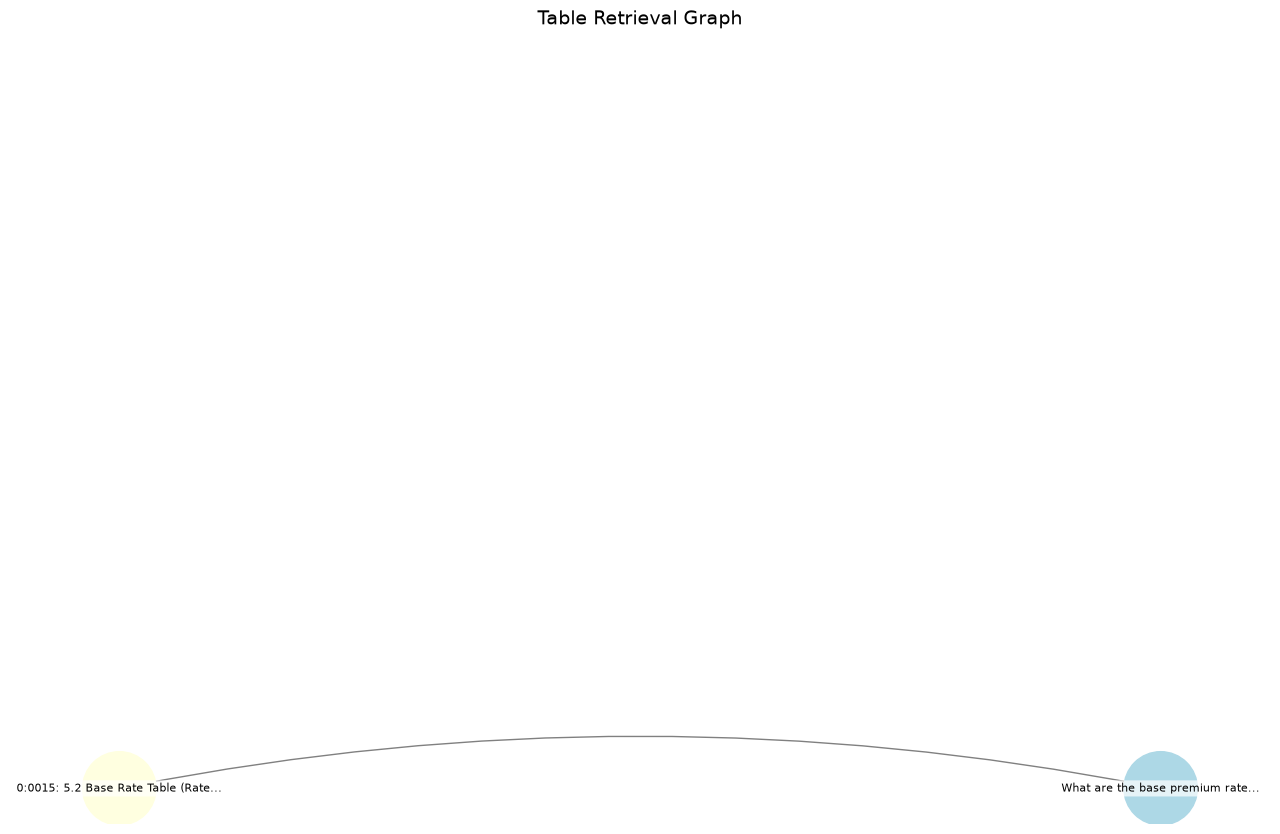

In [24]:
# Block 7e: Visualize the table retrieval graph
try:
    import networkx as nx
    import matplotlib.pyplot as plt
    G = nx.DiGraph()
    _q_label = result_b['question'][:30] + ('...' if len(result_b['question']) > 30 else '')
    G.add_node(_q_label, color='lightblue')
    _node_titles = {}
    for nid in result_b['table_node_ids']:
        _node = node_map.get(nid, {})
        _title = _node.get('title', nid)[:25]
        _full_title = _node.get('title', nid)
        _label = f"{nid}: {_title}" + ('...' if len(_full_title) > 25 else '')
        _node_titles[nid] = _label
        G.add_node(_label, color='lightyellow')
        G.add_edge(_q_label, _label)
    for ref in result_b.get('cross_references', []):
        _src = _node_titles.get(ref.get('from', ''), ref.get('from', ''))
        _tgt = _node_titles.get(ref.get('to', ''), ref.get('to', ''))
        if _src in G.nodes and _tgt in G.nodes:
            G.add_edge(_src, _tgt)
    _colors = [G.nodes[n].get('color', 'white') for n in G.nodes]
    fig, ax = plt.subplots(figsize=(14, 9))
    pos = nx.kamada_kawai_layout(G)
    nx.draw_networkx_nodes(G, pos, node_color=_colors, node_size=2800, ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True,
                           arrowstyle='->', arrowsize=15, ax=ax,
                           connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax,
                            bbox=dict(boxstyle='round,pad=0.2',
                                      facecolor='white', edgecolor='none',
                                      alpha=0.7))
    ax.set_title('Table Retrieval Graph', fontsize=14, pad=12)
    ax.set_axis_off()
    fig.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05)
    plt.show()
except Exception as e:
    print(f"\n(Visualization unavailable: {type(e).__name__}: {e})")